<a href="https://colab.research.google.com/github/BhavyaKyasani/Hospital-Command-Center-Analysis/blob/main/Hospital_ER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
path = "/content/Hospital_ER_Data_FINAL_25000 (1).csv"

df = pd.read_csv(path)

In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (25000, 12)


In [ ]:
print("First 5 Rows")
display(df.head())

print("Last 5 Rows")
display(df.tail())

First 5 Rows


,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,0.0
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,0.0
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,0.0
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,0.0
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,M,5,African American,Orthopedics,False,NaN,10,0.0


Last 5 Rows


,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
24995,PAT016679,2026-04-03 18:36:00,NaN,NaN,Male,1,NaN,Physiotherapy,True,3.5,183,NaN
24996,PAT016680,2026-04-03 19:17:00,NaN,NaN,Male,27,NaN,Orthopedics,False,4.4,5,NaN
24997,PAT016681,2026-04-03 20:42:00,NaN,NaN,Female,30,NaN,Renal,True,3.0,107,NaN
24998,PAT016682,2026-04-03 21:04:00,NaN,NaN,Female,90,NaN,Gastroenterology,False,3.4,144,NaN
24999,PAT016683,2026-04-03 21:55:00,NaN,NaN,Female,71,NaN,Renal,False,3.1,106,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  25000 non-null  object 
 1   Patient Admission Date      25000 non-null  object 
 2   Patient First Inital        9216 non-null   object 
 3   Patient Last Name           9216 non-null   object 
 4   Patient Gender              25000 non-null  object 
 5   Patient Age                 25000 non-null  int64  
 6   Patient Race                9216 non-null   object 
 7   Department Referral         19600 non-null  object 
 8   Patient Admission Flag      25000 non-null  bool   
 9   Patient Satisfaction Score  18301 non-null  float64
 10  Patient Waittime            25000 non-null  int64  
 11  Patients CM                 9216 non-null   float64
dtypes: bool(1), float64(2), int64(2), object(7)
memory usage: 2.1+ MB


In [ ]:
print(df.dtypes)

Patient Id                     object
Patient Admission Date         object
Patient First Inital           object
Patient Last Name              object
Patient Gender                 object
Patient Age                     int64
Patient Race                   object
Department Referral            object
Patient Admission Flag           bool
Patient Satisfaction Score    float64
Patient Waittime                int64
Patients CM                   float64
dtype: object


In [ ]:
display(df.describe(include='all'))

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
count,25000,25000,9216,9216,25000,25000.000000,9216,19600,25000,18301.000000,25000.000000,9216.000000
unique,25000,24960,26,8400,5,NaN,7,7,2,NaN,NaN,NaN
top,PAT016683,16-03-2024 05:02,C,Kilduff,Female,NaN,White,General Practice,False,NaN,NaN,NaN
freq,1,2,383,4,7909,NaN,2571,4141,12602,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,45.074200,NaN,NaN,NaN,3.929610,90.844480,0.052083
std,NaN,NaN,NaN,NaN,NaN,26.153927,NaN,NaN,NaN,1.409674,69.225277,0.222207
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000,5.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,23.000000,NaN,NaN,NaN,3.100000,34.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,NaN,NaN,3.800000,59.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,67.000000,NaN,NaN,NaN,4.500000,148.000000,0.000000


Missing Values:
Patient Id                        0
Patient Admission Date            0
Patient First Inital          15784
Patient Last Name             15784
Patient Gender                    0
Patient Age                       0
Patient Race                  15784
Department Referral            5400
Patient Admission Flag            0
Patient Satisfaction Score     6699
Patient Waittime                  0
Patients CM                   15784
dtype: int64


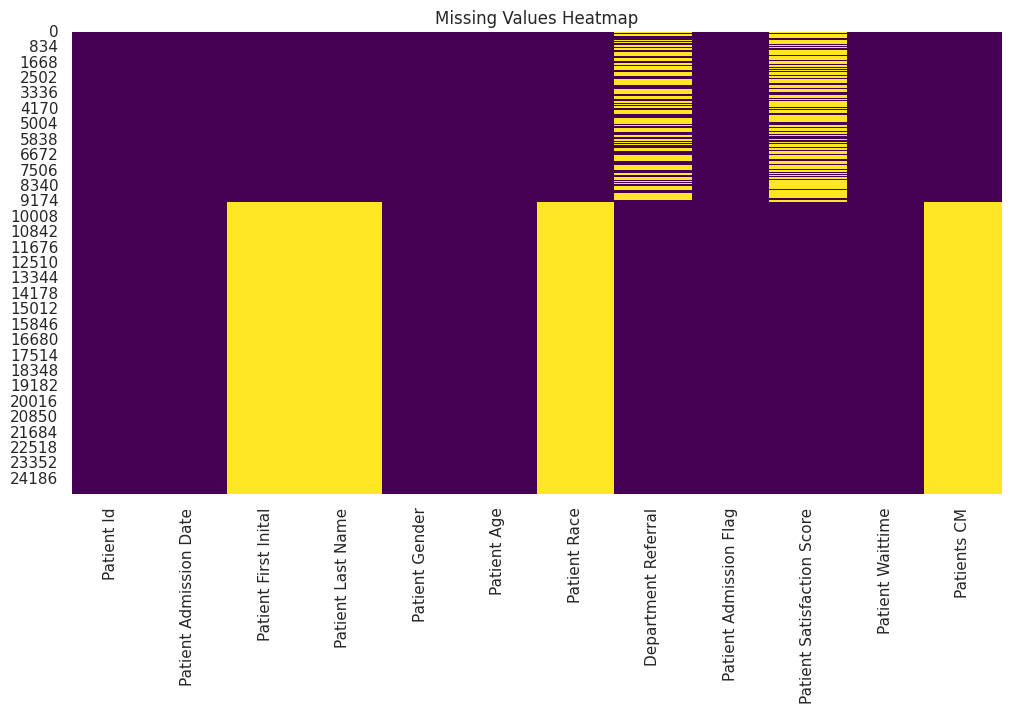

In [ ]:
missing = df.isnull().sum()

print("Missing Values:")
print(missing)

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [ ]:
unique = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
})

display(unique)

,Column,Unique Values
0,Patient Id,25000
1,Patient Admission Date,24960
2,Patient First Inital,26
3,Patient Last Name,8400
4,Patient Gender,5
5,Patient Age,95
6,Patient Race,7
7,Department Referral,7
8,Patient Admission Flag,2
9,Patient Satisfaction Score,34


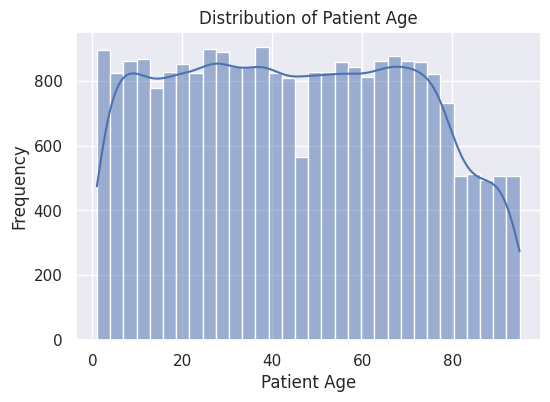

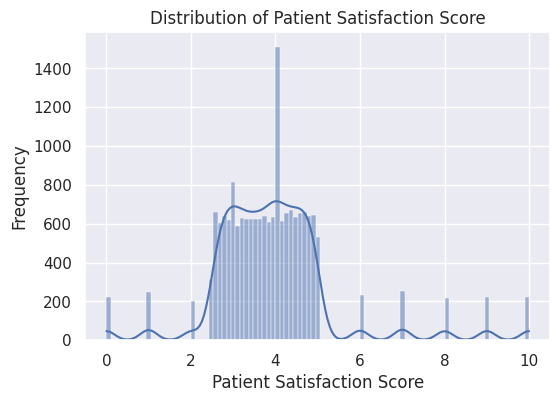

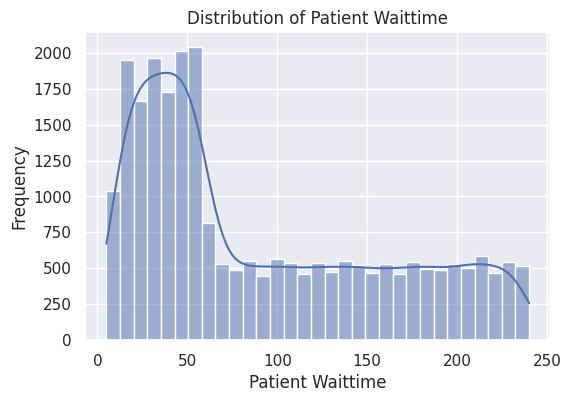

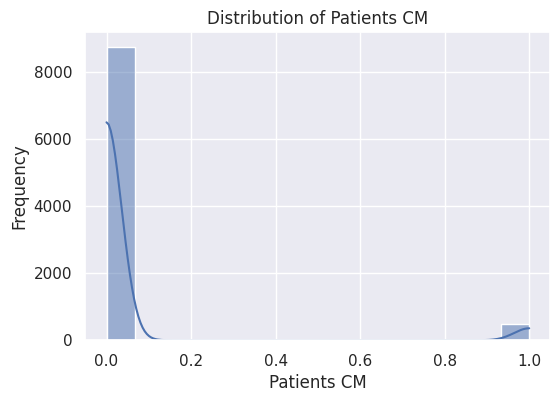

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

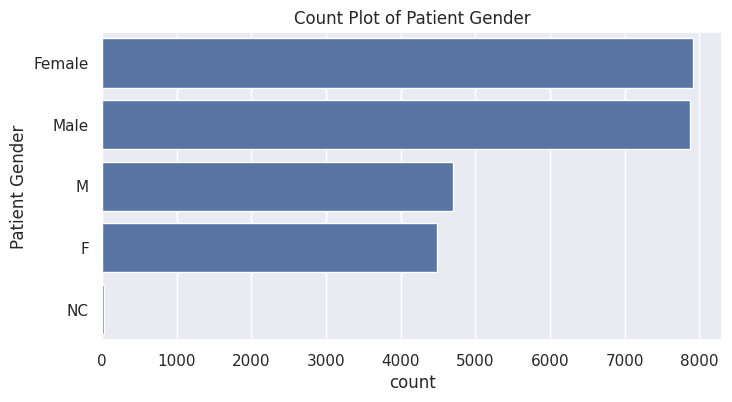

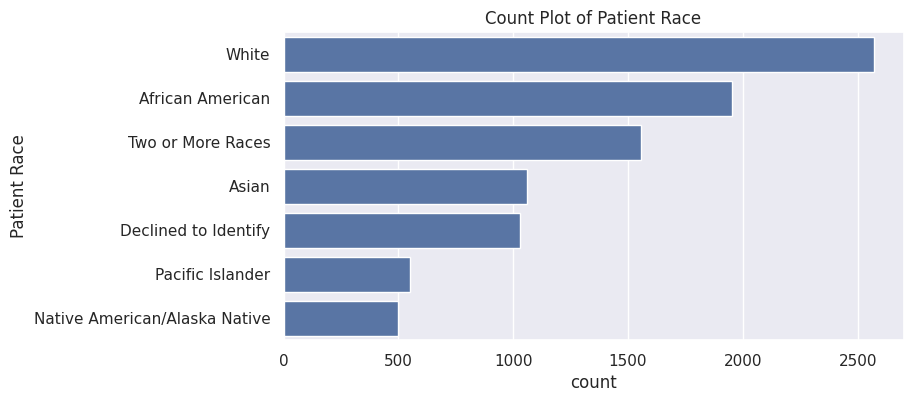

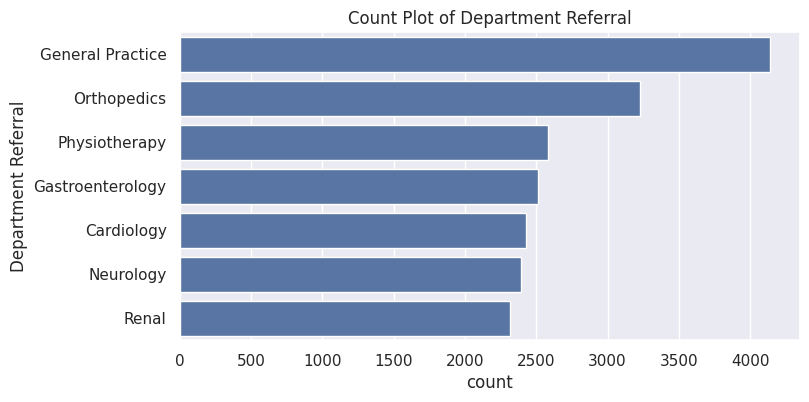

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    if df[col].nunique() <= 20:
        plt.figure(figsize=(8,4))
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f"Count Plot of {col}")
        plt.show()

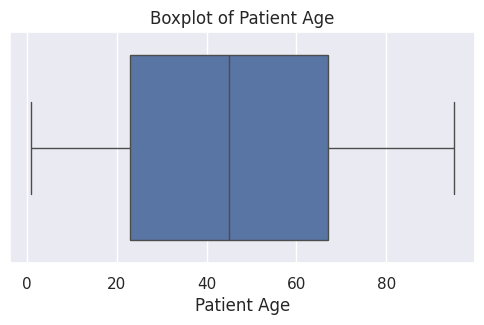

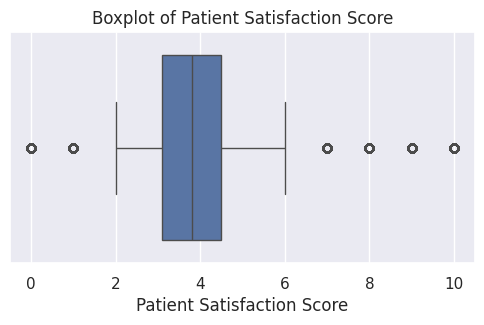

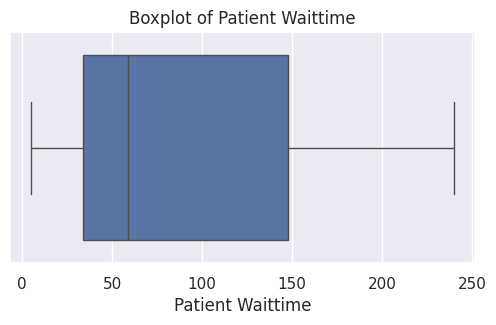

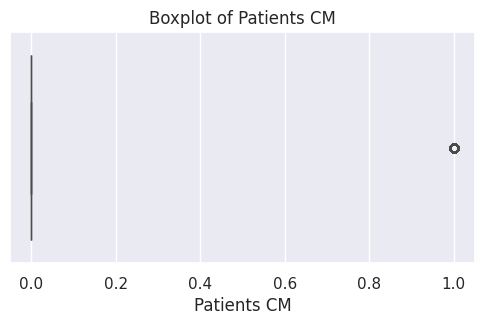

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

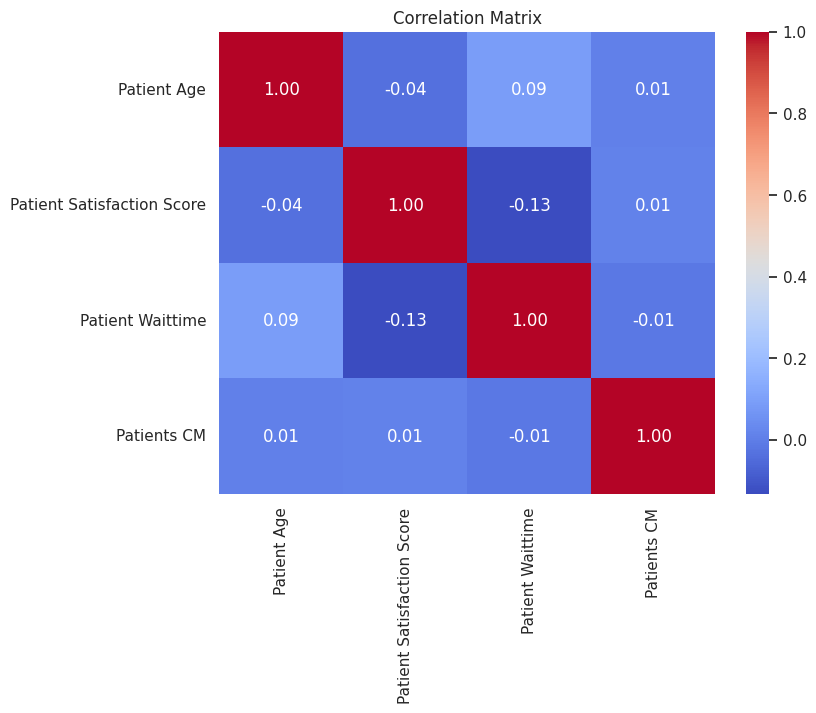

In [ ]:
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
clean_df = df.drop_duplicates()

clean_df.to_csv("/content/Hospital_ER_Data_FINAL_25000_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
